In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/anime-recommendations-database-vol2/ratings.csv
/kaggle/input/anime-recommendations-database-vol2/animes.csv
/kaggle/input/ddpm-anime/pytorch/default/1/ddpm_anime_before_refit.pt
/kaggle/input/movielens-1m-dataset/users.dat
/kaggle/input/movielens-1m-dataset/ratings.dat
/kaggle/input/movielens-1m-dataset/README
/kaggle/input/movielens-1m-dataset/movies.dat
/kaggle/input/ddpm-after/pytorch/default/1/ddpm_yelp_after_refit.pt
/kaggle/input/yelp-dataset/Dataset_User_Agreement.pdf
/kaggle/input/yelp-dataset/yelp_academic_dataset_review.json
/kaggle/input/yelp-dataset/yelp_academic_dataset_checkin.json
/kaggle/input/yelp-dataset/yelp_academic_dataset_business.json
/kaggle/input/yelp-dataset/yelp_academic_dataset_tip.json
/kaggle/input/yelp-dataset/yelp_academic_dataset_user.json
/kaggle/input/ddpm-before/pytorch/default/1/ddpm_yelp_before_refit.pt
/kaggle/input/ddpm-movies/pytorch/default/1/ddpm_before_refit_movielens.pt
/kaggle/input/ddpm-movies/pytorch/default/1/ddpm_refit_ep

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import random
import os
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)


Using device: cuda


In [3]:
# yelp_path = "/kaggle/input/yelp-dataset/yelp_academic_dataset_review.json"

# reviews = pd.read_json(yelp_path, lines=True)[
#     ["user_id", "business_id", "stars"]
# ]

# reviews.head()
import dask.dataframe as dd

yelp_path = "/kaggle/input/yelp-dataset/yelp_academic_dataset_review.json"

# Read lazily. blocksize splits the file into chunks automatically.
# Dask infers the schema from the first chunk.
reviews = dd.read_json(yelp_path, lines=True, blocksize='128MB')

# Select columns (this is instant, no data is loaded yet)
reviews = reviews[["user_id", "business_id", "stars"]]

# Now trigger the calculation only for the rows you need (e.g., the first 5)
print(reviews.head())

/usr/local/lib/python3.12/dist-packages/sqlalchemy/orm/query.py:195: SyntaxWarning: "is not" with 'tuple' literal. Did you mean "!="?
  if entities is not ():


                  user_id             business_id  stars
0  mh_-eMZ6K5RLWhZyISBhwA  XQfwVwDr-v0ZS3_CbbE5Xw      3
1  OyoGAe7OKpv6SyGZT5g77Q  7ATYjTIgM3jUlt4UM3IypQ      5
2  8g_iMtfSiwikVnbP2etR0A  YjUWPpI6HXG530lwP-fb2A      3
3  _7bHUi9Uuf5__HHc_Q8guQ  kxX2SOes4o-D3ZQBkiMRfA      5
4  bcjbaE6dDog4jkNY91ncLQ  e4Vwtrqf-wpJfwesgvdgxQ      4


In [4]:
# # # Encode string IDs to indices
# # user_map = {u:i for i,u in enumerate(reviews.user_id.unique())}
# # item_map = {b:i for i,b in enumerate(reviews.business_id.unique())}

# # reviews["user"] = reviews.user_id.map(user_map)
# # reviews["item"] = reviews.business_id.map(item_map)
# # reviews = reviews[["user","item","stars"]]

# # num_users = reviews.user.nunique()
# # num_items = reviews.item.nunique()

# # print("Users:", num_users)
# # print("Items:", num_items)
# # 1. Convert to 'category' type (this automatically maps strings to integers internally)
# reviews['user_id'] = reviews['user_id'].astype('category')
# reviews['business_id'] = reviews['business_id'].astype('category')

# # 2. Extract the codes (the integers)
# reviews['user'] = reviews['user_id'].cat.codes
# reviews['item'] = reviews['business_id'].cat.codes

# # 3. Filter columns
# reviews = reviews[["user", "item", "stars"]]

# num_users = len(reviews['user_id'].cat.categories)
# num_items = len(reviews['business_id'].cat.categories)

# print("Users:", num_users)
# print("Items:", num_items)

# 2. IMPORTANT: Convert to category and compute the unique categories immediately
# This triggers a computation to scan the entire dataset
reviews = reviews.categorize(columns=['user_id', 'business_id'])
print("here 1")
# 3. Now .cat.codes works because the categories are "known"
reviews['user'] = reviews['user_id'].cat.codes
print("Here 1.5")
reviews['item'] = reviews['business_id'].cat.codes
print("Here 2")
# 4. Keep only the integer columns
reviews = reviews[["user", "item", "stars"]]
# 5. If you need to work with this data in memory now (e.g. for training),
# convert the final result to Pandas
reviews_pd = reviews.compute()

print(reviews_pd.head())

here 1
Here 1.5
Here 2
      user    item  stars
0  1575984   80739      3
1   808641   19425      5
2   301909   83879      3
3  1154325  114801      5
4  1231666   98537      4


In [5]:
num_users = reviews.user.nunique()
num_items = reviews.item.nunique()

print("Users:", num_users)
print("Items:", num_items)

Users: <dask_expr.expr.Scalar: expr=(DropDuplicates(frame=((Assign(frame=Assign(frame=Categorize(frame=ArrowStringConversion(frame=FromDelayed(f9bfffd))[['user_id', 'business_id', 'stars']], categories={'user_id': 65682     ---1lKK3aKOuomHnwAkAow
22278     ---2PmXbF47D870stH1jqA
16593     ---UgP94gokyCDuB5zUssA
95927     ---fa6ZK37T9NjkGKI4oSg
108851    ---r61b7EpVPkb4UVme5tA
                   ...          
155118    zzz-M4QvkEpUWWPL9RTzLA
2509      zzzCg-_lpyYE82TlJCdwdw
94497     zzzGgfvrSJ4AQeKtcgocIw
115382    zzzMBVS73g3ZJ7qL8JyhiA
171690    zzzUFM4HFe0SFG0bPjntQA
Name: user_id, Length: 1987929, dtype: string, 'business_id': 52704     ---kPU91CF4Lq2-WlRu9Lw
9491      --0iUa4sNDFiZFrAdIWhZQ
82381     --30_8IhuyMHbSOcNWd6DQ
133328    --7PUidqRWpRSpXebiyxTg
134665    --7jw19RH9JKXgFohspgQw
                   ...          
86271     zznZqH9CiAznbkV6fXyHWA
104695    zztOG2cKm87I6Iw_tleZsQ
87089     zzu6_r3DxBJuXcjnOYVdTw
34492     zzw66H6hVjXQEt0Js3Mo4A
23178     zzyx5x0Z7xXWWvWnZFuxl

In [6]:
# def train_test_split_userwise(df, test_ratio=0.2):
#     train, test = [], []
#     for uid, group in df.groupby("user"):
#         group = group.sample(frac=1, random_state=42)
#         n_test = int(len(group) * test_ratio)
#         test.append(group.iloc[:n_test])
#         train.append(group.iloc[n_test:])
#     return pd.concat(train), pd.concat(test)

# train_df, test_df = train_test_split_userwise(reviews_pd)
# print("Train size:", len(train_df))
# print("Test size:", len(test_df))
def train_test_split_userwise_optimized(df, test_ratio=0.2):
    # 1. Shuffle the entire dataset globally (so the order is random)
    # reset_index is important so we can align calculations later
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    # 2. Get the total count of reviews for each user
    # transform('count') returns a Series same length as df
    user_counts = df.groupby('user')['user'].transform('count')

    # 3. Create a counter (0, 1, 2...) for each review within each user group
    # Since we shuffled in step 1, this acts as a random rank
    user_cumcount = df.groupby('user').cumcount()

    # 4. Create the mask
    # If a review is the 0th or 1st item (cumcount) and the user has 10 items (count),
    # 0 < 2 is True. It goes to Test.
    mask_test = user_cumcount < (user_counts * test_ratio).astype(int)

    # 5. Split using the mask
    test_df = df[mask_test]
    train_df = df[~mask_test]

    return train_df, test_df

# Run the optimized function
train_df, test_df = train_test_split_userwise_optimized(reviews_pd)

print("Train size:", len(train_df))
print("Test size:", len(test_df))

Train size: 6200580
Test size: 789700


In [7]:
# Calculate dimensions from the full dataframe (before splitting if possible)
# or the maximum found in your train/test splits
num_users = reviews_pd['user'].max() + 1
num_items = reviews_pd['item'].max() + 1

print(f"Users: {num_users}, Items: {num_items}")

Users: 1987929, Items: 150346


In [8]:
# def build_matrix(df, num_users, num_items):
#     mat = np.zeros((num_users, num_items), dtype=np.float32)
#     for r in df.itertuples():
#         mat[r.user, r.item] = r.stars
#     return mat

# train_matrix = build_matrix(train_df, num_users, num_items)
# test_matrix  = build_matrix(test_df,  num_users, num_items)

# train_tensor = torch.FloatTensor(train_matrix).to(DEVICE)
import torch

def build_sparse_tensor(df, num_users, num_items, device):
    # 1. Extract coordinates (rows, cols) and values
    # We use .values to get numpy arrays for speed
    indices = torch.LongTensor([df['user'].values, df['item'].values])
    values = torch.FloatTensor(df['stars'].values)
    
    # 2. Create the Sparse Tensor
    shape = torch.Size([num_users, num_items])
    sparse_tensor = torch.sparse_coo_tensor(indices, values, shape).to(device)
    
    return sparse_tensor

# Usage
train_tensor = build_sparse_tensor(train_df, num_users, num_items, DEVICE)
test_tensor  = build_sparse_tensor(test_df,  num_users, num_items, DEVICE)

print("Sparse tensor created successfully!")
print(train_tensor)

/tmp/ipykernel_55/2868001618.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  indices = torch.LongTensor([df['user'].values, df['item'].values])


Sparse tensor created successfully!
tensor(indices=tensor([[1217664,  760697,  815133,  ..., 1958768, 1734658,
                         828399],
                       [ 124684,   23468,   82003,  ...,      81,   76531,
                         134730]]),
       values=tensor([5., 5., 4.,  ..., 3., 4., 5.]),
       device='cuda:0', size=(1987929, 150346), nnz=6200580,
       layout=torch.sparse_coo)


In [5]:
class TimestepEmbed(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, t):
        half = self.dim // 2
        emb = np.log(10000) / (half - 1)
        emb = torch.exp(torch.arange(half, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        return torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)

class DenoisingNet(nn.Module):
    def __init__(self, n_items, h=512, t_dim=128):
        super().__init__()
        self.t_emb = TimestepEmbed(t_dim)
        self.fc1 = nn.Linear(n_items + t_dim, h)
        self.fc2 = nn.Linear(h, h)
        self.fc_out = nn.Linear(h, n_items)
        self.ln1 = nn.LayerNorm(h)
        self.ln2 = nn.LayerNorm(h)
        self.drop = nn.Dropout(0.1)
    
    def forward(self, x, t):
        t_e = self.t_emb(t)
        h = torch.cat([x, t_e], dim=-1)
        h1 = self.drop(F.relu(self.ln1(self.fc1(h))))
        h2 = self.drop(F.relu(self.ln2(self.fc2(h1))))
        return self.fc_out(h2 + h1)

class DDPM(nn.Module):
    def __init__(self, n_items, steps=50):
        super().__init__()
        self.steps = steps
        
        betas = torch.linspace(0.0001, 0.02, steps)
        alphas = 1 - betas
        alphas_bar = torch.cumprod(alphas, 0)
        alphas_bar_prev = torch.cat([torch.ones(1), alphas_bar[:-1]])

        self.register_buffer('betas', betas)
        self.register_buffer('alphas', alphas)
        self.register_buffer('alphas_bar', alphas_bar)
        self.register_buffer('sqrt_alphas_bar', torch.sqrt(alphas_bar))
        self.register_buffer('sqrt_one_minus_alphas_bar', torch.sqrt(1 - alphas_bar))

        post_var = betas * (1 - alphas_bar_prev) / (1 - alphas_bar)
        self.register_buffer('post_var', post_var)
        self.register_buffer('post_coef1', betas * torch.sqrt(alphas_bar_prev) / (1 - alphas_bar))
        self.register_buffer('post_coef2', (1 - alphas_bar_prev) * torch.sqrt(alphas) / (1 - alphas_bar))

        self.net = DenoisingNet(n_items)

    def _get(self, arr, t, shape):
        r = arr[t]
        while len(r.shape) < len(shape):
            r = r[..., None]
        return r.expand(shape)

    def q_sample(self, x0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x0)
        return self._get(self.sqrt_alphas_bar, t, x0.shape) * x0 + \
               self._get(self.sqrt_one_minus_alphas_bar, t, x0.shape) * noise

    def q_posterior(self, x0, xt, t):
        mean = self._get(self.post_coef1, t, xt.shape) * x0 + \
               self._get(self.post_coef2, t, xt.shape) * xt
        var = self._get(self.post_var, t, xt.shape)
        return mean, var

    def loss(self, x0):
        bs = x0.size(0)
        t = torch.randint(0, self.steps, (bs,), device=x0.device)
        noise = torch.randn_like(x0)
        xt = self.q_sample(x0, t, noise)
        pred_x0 = self.net(xt, t)
        mask = (x0 > 0).float()
        return (F.mse_loss(pred_x0, x0, reduction='none') * mask).sum() / (mask.sum() + 1e-8)

    def sample_with_logp(self, x_init, cond=None, mask=None):
        xt = x_init
        logps = []

        for i in reversed(range(self.steps)):
            t = torch.full((xt.size(0),), i, device=xt.device, dtype=torch.long)
            pred_x0 = torch.clamp(self.net(xt, t), 0, 5)
            mean, var = self.q_posterior(pred_x0, xt, t)
            std = torch.sqrt(var)

            noise = torch.randn_like(xt) if i > 0 else 0
            xt_next = mean + std * noise

            if cond is not None and mask is not None:
                xt_next = xt_next * (1 - mask) + cond * mask

            if i > 0:
                logp = -((xt_next.detach() - mean) ** 2) / (2 * var + 1e-8) \
                       - torch.log(std + 1e-8) - 0.5 * np.log(2 * np.pi)
                logps.append(logp)

            xt = xt_next

        logps = torch.stack(logps).transpose(0, 1).mean(dim=tuple(range(1, logps[0].dim() + 1)))
        return logps, xt


In [27]:
# 1. Hyperparameters
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 1  # We process one user at a time (which effectively acts as a batch of items)
LR = 1e-3
EPOCHS = 5

# 2. Instantiate Model
# num_items comes from your previous code: reviews_pd['item'].max() + 1
model = DDPM(n_items=num_items, steps=50).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# 1. Define Sampling Settings
sample_ratio = 0.1  # 1% of data
num_samples = int(num_users * sample_ratio)

# 2. Select Random Indices
# We pick random User IDs to train on for this epoch
# replace=False ensures we don't pick the same user twice in one epoch
subset_indices = np.random.choice(num_users, size=num_samples, replace=False)

print(f"Training on {num_samples} users (1% subset) instead of {num_users}...")
# # 3. Training Loop
# model.train()

# for ep in range(EPOCHS):
#     total_loss = 0
    
#     # Iterate over every user (Row by Row)
#     for u in tqdm(range(num_users), desc=f"DDPM Epoch {ep+1}"):
        
#         # A. Get the Sparse Vector for User u
#         # Shape: [num_items] (mostly zeros)
#         x0_sparse = train_tensor[u]
        
        # # B. CRITICAL FIX: Convert to Dense immediately
        # # We need a dense vector because Gaussian noise is never 0.
        # # unsqueeze(0) makes it shape [1, num_items] to simulate batch size of 1
        # x0 = x0_sparse.to_dense().unsqueeze(0)
        
        # # C. Calculate Loss
        # # Now x0 is a standard dense tensor, so torch.randn_like(x0) inside the model will work.
        # loss = model.loss(x0)
        
        # # D. Backpropagation
        # optimizer.zero_grad()
#         loss.backward()
#         optimizer.step()
        
#         total_loss += loss.item()

#     avg_loss = total_loss / num_users
#     print(f"Epoch {ep+1} | Average Loss: {avg_loss:.4f}")

# print("Training Complete.")

# 3. Modified Training Loop
model.train()

for ep in range(EPOCHS):
    total_loss = 0
    
    # Iterate ONLY over the random subset
    for u in tqdm(subset_indices, desc=f"DDPM Epoch {ep+1} (1% Data)"):
        
        # A. Get Sparse Vector (No change in logic)
        x0_sparse = train_tensor[u]
        
        # B. Convert to Dense (Your fix)
        x0 = x0_sparse.to_dense().unsqueeze(0)
        
        # C. Loss & Backprop (No change in logic)
        loss = model.loss(x0)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()

    # Calculate average over the subset size, not total users
    avg_loss = total_loss / num_samples
    print(f"Epoch {ep+1} | Average Loss: {avg_loss:.4f}")

print("Training Complete.")

Training on 198792 users (1% subset) instead of 1987929...


DDPM Epoch 1 (1% Data): 100%|██████████| 198792/198792 [1:27:49<00:00, 37.72it/s]


Epoch 1 | Average Loss: 6.6869


DDPM Epoch 2 (1% Data): 100%|██████████| 198792/198792 [1:27:38<00:00, 37.80it/s]


Epoch 2 | Average Loss: 4.0293


...

Epoch 3 | Average Loss: 3.3313


DDPM Epoch 4 (1% Data): 100%|██████████| 198792/198792 [1:27:43<00:00, 37.77it/s]


Epoch 4 | Average Loss: 2.9549


DDPM Epoch 5 (1% Data): 100%|██████████| 198792/198792 [1:27:34<00:00, 37.83it/s]

Epoch 5 | Average Loss: 2.7947
Training Complete.


In [28]:
SAVE_DIR = "/kaggle/working/models"
os.makedirs(SAVE_DIR, exist_ok=True)

torch.save({
    "model_state_dict": model.state_dict(),
    "num_items": num_items
}, f"{SAVE_DIR}/ddpm_yelp_before_refit.pt")
print("✅ Model saved BEFORE ReFiT")


✅ Model saved BEFORE ReFiT


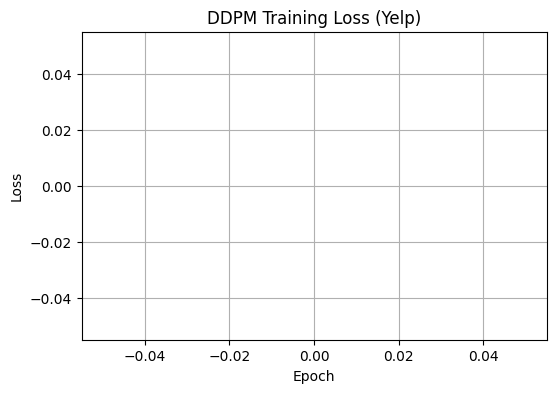

In [29]:
plt.figure(figsize=(6,4))
plt.plot(ddpm_losses, marker='o')
plt.title("DDPM Training Loss (Yelp)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()
plt.show()


In [33]:
# class PearsonReward:
#     def __init__(self, train_m, test_m, dev, K=10, alpha=0.5, beta=0.3, gamma=0.2, tau=0.3):
#         self.train_m = train_m
#         self.test_m = test_m
#         self.dev = dev
#         self.K = K
#         self.alpha, self.beta, self.gamma = alpha, beta, gamma
#         self.tau = tau
        
#         self.train_t = torch.FloatTensor(train_m).to(dev)
#         self.test_t = torch.FloatTensor(test_m).to(dev)
#         self.items_t = self.train_t.T
#         self.nu, self.ni = train_m.shape
    
#     def pearson(self, x, y, eps=1e-8):
#         xm, ym = x.mean(), y.mean()
#         xc, yc = x - xm, y - ym
#         return torch.sum(xc * yc) / (torch.sqrt(torch.sum(xc**2)) * torch.sqrt(torch.sum(yc**2)) + eps)
    
#     def item_sim(self, item_id, liked):
#         if len(liked) == 0:
#             return 0.0
#         iv = self.items_t[item_id]
#         sims = [self.pearson(iv, self.items_t[j]) for j in liked]
#         return torch.stack(sims).max().item()
    
#     def similar_users(self, uid, topk=10):
#         targ = self.train_t[uid]
#         sims = [self.pearson(targ, self.train_t[u]) if u != uid else -1 for u in range(self.nu)]
#         return torch.tensor(sims, device=self.dev).topk(topk).indices
    
#     def reward(self, uid, pred):
#         topk = torch.topk(pred, self.K).indices.cpu().numpy()
#         true_items = set(np.where(self.test_m[uid] > 1)[0])
#         Nk = len(set(topk) & true_items)

#         sim_us = self.similar_users(uid)
#         Nsim = sum(len(set(topk) & set(np.where(self.test_m[su.item()] > 1)[0])) for su in sim_us)

#         liked = np.where(self.train_m[uid] > 2)[0]
#         sim_r = sum(self.item_sim(it, liked) for it in topk if it not in true_items and self.item_sim(it, liked) > self.tau)

#         return self.alpha * Nk + self.beta * Nsim + self.gamma * sim_r
    
#     def batch_reward(self, uids, preds):
#         return torch.FloatTensor([self.reward(uid, preds[i]) for i, uid in enumerate(uids)])

# reward_fn = PearsonReward(train_tensor, test_tensor, DEVICE)
import torch
import numpy as np

class PearsonReward:
    def __init__(self, train_sparse, test_sparse, dev, K=10, alpha=0.5, beta=0.3, gamma=0.2, tau=0.3):
        self.train_sparse = train_sparse
        self.test_sparse = test_sparse
        self.dev = dev
        self.K = K
        self.alpha, self.beta, self.gamma = alpha, beta, gamma
        self.tau = tau
        
        # We need the transpose for fast item access (Item-User view)
        # Note: Transposing a sparse tensor can be expensive, do it once here if possible.
        # Ideally, pass a pre-transposed version if you have it. 
        self.items_sparse = self.train_sparse.t().coalesce()
        
        self.nu = train_sparse.size(0)
        self.ni = train_sparse.size(1)
    
    def pearson(self, x, y, eps=1e-8):
        # x and y must be dense 1D tensors
        xm, ym = x.mean(), y.mean()
        xc, yc = x - xm, y - ym
        numerator = torch.sum(xc * yc)
        denominator = torch.sqrt(torch.sum(xc**2)) * torch.sqrt(torch.sum(yc**2)) + eps
        return numerator / denominator
    
    def item_sim(self, item_id, liked_items_indices):
        if len(liked_items_indices) == 0:
            return 0.0
        
        # 1. Get the target item vector (Sparse -> Dense)
        iv = self.items_sparse[item_id].to_dense()
        
        # 2. Compare with liked items
        # Optimization: We loop only through items the user ACTUALLY liked
        sims = []
        for j in liked_items_indices:
            jv = self.items_sparse[j].to_dense()
            sims.append(self.pearson(iv, jv))
            
        if not sims: return 0.0
        return torch.stack(sims).max().item()
    
    def similar_users(self, uid, topk=10):
        # 1. Get target user vector (Sparse -> Dense)
        targ = self.train_sparse[uid].to_dense()
        
        # --- CRITICAL SPEED FIX ---
        # Comparing against ALL 2M users is impossible. 
        # We compare against a random sample of 50 users to approximate.
        sample_size = 50 
        random_users = torch.randint(0, self.nu, (sample_size,), device=self.dev)
        
        sims = []
        indices = []
        
        for u in random_users:
            if u == uid: continue
            
            u_vec = self.train_sparse[u].to_dense()
            sim = self.pearson(targ, u_vec)
            
            sims.append(sim)
            indices.append(u)
            
        sims = torch.stack(sims)
        indices = torch.stack(indices)
        
        # Get top K from this sample
        # Handle case where sample is smaller than topk
        curr_k = min(topk, len(sims))
        if curr_k == 0: return torch.tensor([], device=self.dev)
        
        best_indices = sims.topk(curr_k).indices
        return indices[best_indices]

    def reward(self, uid, pred):
        # 1. Get Top K predictions
        topk = torch.topk(pred, self.K).indices
        topk_list = topk.cpu().numpy()
        
        # 2. Get True Items (Ground Truth for this user) from Test Set
        # Access sparse tensor efficiently
        test_row = self.test_sparse[uid].coalesce() 
        true_items_indices = test_row.indices()[0] # The indices of non-zero elements
        true_items_set = set(true_items_indices.cpu().numpy())
        
        # --- Term 1: Nk (Precision@K) ---
        Nk = len(set(topk_list) & true_items_set)

        # --- Term 2: Nsim (Social Recommendation) ---
        sim_us = self.similar_users(uid)
        Nsim = 0
        if len(sim_us) > 0:
            for su in sim_us:
                # Get items liked by similar user 'su'
                su_row = self.test_sparse[su].coalesce()
                su_items = set(su_row.indices()[0].cpu().numpy())
                Nsim += len(set(topk_list) & su_items)

        # --- Term 3: sim_r (Content/Item Similarity) ---
        # Get items liked by CURRENT user in TRAIN set
        train_row = self.train_sparse[uid].coalesce()
        liked_indices = train_row.indices()[0] # Indices where rating exists
        
        # Filter: only calculate if rating > 2 (approximate check, assuming sparse only holds valid ratings)
        # If your sparse matrix contains zeros for explicit 0 ratings, you need values check:
        # liked_vals = train_row.values()
        # valid_mask = liked_vals > 2
        # liked_indices = liked_indices[valid_mask]

        sim_r = 0.0
        for it in topk_list:
            if it not in true_items_set:
                score = self.item_sim(it, liked_indices)
                if score > self.tau:
                    sim_r += score

        return self.alpha * Nk + self.beta * Nsim + self.gamma * sim_r

    def batch_reward(self, uids, preds):
        rewards = []
        for i, uid in enumerate(uids):
            r = self.reward(uid, preds[i])
            rewards.append(r)
        return torch.tensor(rewards, device=self.dev)

# --- INSTANTIATE WITH SPARSE TENSORS ---
# Ensure your train_tensor and test_tensor are coalesced for faster indexing
train_tensor = train_tensor.coalesce()
test_tensor = test_tensor.coalesce()

reward_fn = PearsonReward(train_tensor, test_tensor, DEVICE)
print("Reward function initialized successfully!")

Reward function initialized successfully!


In [35]:
# rl_optimizer = Adam(model.parameters(), lr=5e-4)
# RL_EPOCHS = 5
# rl_rewards = []

# for ep in range(RL_EPOCHS):
#     total_r = 0
#     for uid in tqdm(range(num_users), desc=f"RL Epoch {ep+1}"):
#         cond = train_tensor[uid].unsqueeze(0)
#         mask = (cond > 0).float()
#         x_init = torch.randn_like(cond)

#         logp, pred = model.sample_with_logp(x_init, cond, mask)
#         r = reward_fn.reward(uid, pred.squeeze())

#         loss = -(logp * r).mean()
#         rl_optimizer.zero_grad()
#         loss.backward()
#         rl_optimizer.step()

#         total_r += r

#     avg_r = total_r / num_users
#     rl_rewards.append(avg_r)
#     print(f"Epoch {ep+1} | Avg Reward: {avg_r:.4f}")
import torch
import numpy as np
from tqdm import tqdm

rl_optimizer = Adam(model.parameters(), lr=5e-4)
RL_EPOCHS = 5

# Change 1: Store rewards per step (iteration), not per epoch
step_rewards = []

# Change 2: Calculate the size of the 1% subset
subset_size = int(num_users * 0.01)
if subset_size < 1: subset_size = 1 # Ensure at least one user is processed

for ep in range(RL_EPOCHS):
    
    subset_indices = np.random.choice(num_users, subset_size, replace=False)
    
    for uid in tqdm(subset_indices, desc=f"RL Epoch {ep+1} (Subset 1%)"):
        # FIX: Add .to_dense() here to convert the sparse row to a standard tensor
        cond = train_tensor[uid].to_dense().unsqueeze(0)
        
        # Now this comparison will work
        mask = (cond > 0).float()
        
        x_init = torch.randn_like(cond)

        logp, pred = model.sample_with_logp(x_init, cond, mask)
        r = reward_fn.reward(uid, pred.squeeze())

        loss = -(logp * r).mean()
        rl_optimizer.zero_grad()
        loss.backward()
        rl_optimizer.step()

        step_rewards.append(r.item() if isinstance(r, torch.Tensor) else r)

    current_epoch_avg = sum(step_rewards[-subset_size:]) / subset_size
    print(f"Epoch {ep+1} | Last {subset_size} steps Avg Reward: {current_epoch_avg:.4f}")

RL Epoch 1 (Subset 1%): 100%|██████████| 19879/19879 [2:29:18<00:00,  2.22it/s]  


Epoch 1 | Last 19879 steps Avg Reward: 0.2592


RL Epoch 2 (Subset 1%):   0%|          | 22/19879 [00:09<2:27:32,  2.24it/s]


KeyboardInterrupt: 

In [36]:
torch.save({
    "model_state_dict": model.state_dict(),
    "num_items": num_items
}, f"{SAVE_DIR}/ddpm_yelp_after_refit.pt")
print("✅ Model saved AFTER ReFiT")


✅ Model saved AFTER ReFiT


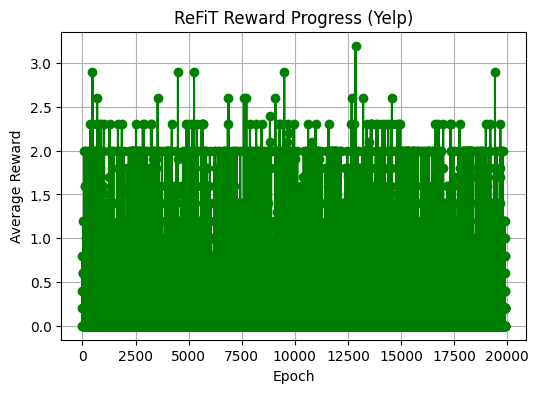

In [37]:
plt.figure(figsize=(6,4))
plt.plot(step_rewards, marker='o', color='green')
plt.title("ReFiT Reward Progress (Yelp)")
plt.xlabel("Epoch")
plt.ylabel("Average Reward")
plt.grid()
plt.show()


In [13]:
# 1. Hyperparameters
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 1  # We process one user at a time (which effectively acts as a batch of items)
LR = 1e-3
EPOCHS = 5

# 2. Instantiate Model
# # num_items comes from your previous code: reviews_pd['item'].max() + 1
model_before = DDPM(n_items=num_items, steps=50).to(DEVICE)
# model_before.load_state_dict(torch.load("/kaggle/input/ddpm-before/pytorch/default/1/ddpm_yelp_before_refit.pt"))
# model_before.to('cuda')
# 1. Load the checkpoint dictionary first
checkpoint = torch.load("/kaggle/input/ddpm-before/pytorch/default/1/ddpm_yelp_before_refit.pt", map_location=DEVICE)

# 2. Extract the actual weights using the key 'model_state_dict'
model_before.load_state_dict(checkpoint['model_state_dict'])

model_before.to(DEVICE)
print("Model loaded successfully!")

Model loaded successfully!


In [20]:
import numpy as np
import time
from tqdm import tqdm
from collections import defaultdict

def evaluate_ddpm(model, train_df, test_df, num_users, num_items, k=10, threshold=2.5, sample_ratio=0.1, device='cuda'):
    """
    Evaluates the DDPM model on a sample of test users.
    
    Args:
        model: The PyTorch DDPM model.
        train_df: Pandas DataFrame containing training data [user, item, stars].
        test_df: Pandas DataFrame containing test data [user, item, stars].
        num_users: Total number of users.
        num_items: Total number of items.
        k: Top-k items to recommend.
        threshold: Rating threshold to consider an item 'relevant'.
        sample_ratio: Fraction of users to evaluate (e.g., 0.1 for 10%).
        device: 'cuda' or 'cpu'.
    """
    model.eval()
    print(f"Starting Evaluation on {sample_ratio*100}% of users...")

    # --- 1. Data Preparation ---
    # Convert Test DF to User->Item->Rating Dictionary for fast lookup
    print("Building ground truth dictionaries...")
    test_user_items = defaultdict(dict)
    for _, row in test_df.iterrows():
        test_user_items[int(row['user'])][int(row['item'])] = row['stars']

    # Convert Train DF to User->Set(Items) to exclude seen items
    train_user_items = defaultdict(set)
    # Also build a sparse matrix-like structure if needed for the model condition
    # For simplicity, we will build the condition vector on the fly inside the loop
    train_data_grouped = train_df.groupby('user')
    
    for user, group in train_data_grouped:
        train_user_items[user] = set(group['item'].values)

    # Filter users who are in both train and test
    test_users_with_history = [u for u in test_user_items.keys() if u in train_user_items]
    
    # --- 2. Subsampling ---
    # Randomly select a percentage of users to evaluate to save time
    num_eval_users = int(len(test_users_with_history) * sample_ratio)
    if num_eval_users < 1: num_eval_users = 1
    eval_users = np.random.choice(test_users_with_history, num_eval_users, replace=False)
    
    print(f"Evaluating on {len(eval_users)} users...")

    # --- 3. Metrics Initialization ---
    sum_precision, sum_recall, sum_ndcg, sum_hit_rate = 0, 0, 0, 0
    rmse_sse, rmse_count = 0, 0
    
    start_time = time.time()

    # --- 4. Main Evaluation Loop ---
    with torch.no_grad():
        for uid in tqdm(eval_users, desc="Generating Recommendations"):
            
            # A. Prepare Input (Conditioning on User History)
            # Create a dense vector of size (1, num_items) for this user
            # This mimics 'train_tensor[uid]'
            u_items = list(train_user_items[uid])
            u_ratings = train_data_grouped.get_group(uid)['stars'].values
            
            # Construct condition tensor
            cond = torch.zeros((1, num_items), device=device)
            cond[0, u_items] = torch.tensor(u_ratings, dtype=torch.float32, device=device)
            
            mask = (cond > 0).float()
            x_init = torch.randn_like(cond)

            # B. Model Inference
            # Using the sample function you showed earlier
            # We assume model returns (logp, pred) or just pred. 
            # If it returns a tuple, we take the second element (prediction)
            ret = model.sample_with_logp(x_init, cond, mask)
            if isinstance(ret, tuple):
                _, pred = ret
            else:
                pred = ret
            
            # Flatten prediction to 1D array on CPU
            pred_scores = pred.squeeze().detach().cpu().numpy()

            # C. Mask Training Items
            # We set the score of items already seen in training to -inf 
            # so they are never recommended
            pred_scores[u_items] = -np.inf

            # D. Generate Top-K Recommendations
            # Get indices of top K scores
            top_k_indices = np.argpartition(-pred_scores, k)[:k]
            # Sort the top k (argpartition is not sorted)
            top_k_indices = top_k_indices[np.argsort(-pred_scores[top_k_indices])]
            
            # E. Calculate Ranking Metrics
            relevant_items = {item for item, rating in test_user_items[uid].items() if rating >= threshold}
            
            if len(relevant_items) > 0:
                # Hits
                hits = [item for item in top_k_indices if item in relevant_items]
                n_hits = len(hits)

                # Precision & Recall
                sum_precision += n_hits / k
                sum_recall += n_hits / len(relevant_items)
                sum_hit_rate += 1.0 if n_hits > 0 else 0.0

                # NDCG
                dcg = sum([1.0 / np.log2(idx + 2) for idx, item in enumerate(top_k_indices) if item in relevant_items])
                idcg = sum([1.0 / np.log2(idx + 2) for idx in range(min(k, len(relevant_items)))])
                sum_ndcg += (dcg / idcg) if idcg > 0 else 0.0
            
            # F. Calculate RMSE (Prediction Accuracy on Test Items)
            # We check the predicted score vs actual rating for items in the test set
            for iid, true_rating in test_user_items[uid].items():
                pred_rating = pred_scores[iid]
                # Only calculate if prediction is valid (not -inf)
                if pred_rating > -9999: 
                    rmse_sse += (pred_rating - true_rating) ** 2
                    rmse_count += 1

    # --- 5. Final Calculation ---
    n_users = len(eval_users)
    metrics = {
        "RMSE": np.sqrt(rmse_sse / rmse_count) if rmse_count > 0 else 0,
        f"Precision@{k}": sum_precision / n_users,
        f"Recall@{k}": sum_recall / n_users,
        f"NDCG@{k}": sum_ndcg / n_users,
        f"Hit Rate@{k}": sum_hit_rate / n_users,
        "Time (s)": time.time() - start_time
    }
    
    return metrics

In [21]:
print("=== Evaluating Base Model ===")
train_df = train_df.drop_duplicates(subset=['user', 'item'], keep='last')
base_metrics = evaluate_ddpm(
    model_before, 
    train_df, 
    test_df, 
    num_users, 
    num_items, 
    k=10, 
    sample_ratio=0.01  # Use 1% of users for speed
)
print("Base Model Results:", base_metrics)

=== Evaluating Base Model ===
Starting Evaluation on 1.0% of users...
Building ground truth dictionaries...
Evaluating on 2871 users...


Generating Recommendations: 100%|██████████| 2871/2871 [03:22<00:00, 14.17it/s]


Base Model Results: {'RMSE': np.float64(1.7173251886001974), 'Precision@10': 3.483106931382794e-05, 'Recall@10': 1.2010713556492392e-05, 'NDCG@10': np.float64(2.4183637038236597e-05), 'Hit Rate@10': 0.00034831069313827936, 'Time (s)': 202.58681273460388}


In [22]:
# 1. Load the checkpoint dictionary first
model_after= DDPM(n_items=num_items, steps=50).to(DEVICE)
checkpoint = torch.load("/kaggle/input/ddpm-before/pytorch/default/1/ddpm_yelp_before_refit.pt", map_location=DEVICE)

# 2. Extract the actual weights using the key 'model_state_dict'
model_after.load_state_dict(checkpoint['model_state_dict'])

model_after.to(DEVICE)
print("Model loaded successfully!")

Model loaded successfully!


In [23]:
print("=== Evaluating Base Model ===")
train_df = train_df.drop_duplicates(subset=['user', 'item'], keep='last')
base_metrics = evaluate_ddpm(
    model_after, 
    train_df, 
    test_df, 
    num_users, 
    num_items, 
    k=10, 
    sample_ratio=0.01  # Use 1% of users for speed
)
print("Base Model Results:", base_metrics)

=== Evaluating Base Model ===
Starting Evaluation on 1.0% of users...
Building ground truth dictionaries...
Evaluating on 2871 users...


Generating Recommendations: 100%|██████████| 2871/2871 [03:21<00:00, 14.24it/s]

Base Model Results: {'RMSE': np.float64(1.7741570278397951), 'Precision@10': 3.483106931382794e-05, 'Recall@10': 0.00017415534656913968, 'NDCG@10': np.float64(8.261849974548806e-05), 'Hit Rate@10': 0.00034831069313827936, 'Time (s)': 201.62231540679932}


In [24]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("odedgolden/movielens-1m-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/movielens-1m-dataset


In [25]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import random

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
import pandas as pd

ratings_path = "/kaggle/input/movielens-1m-dataset/ratings.dat"

ratings = pd.read_csv(
    ratings_path,
    sep="::",
    engine="python",
    names=["user", "item", "rating", "timestamp"]
)

# Indexation à partir de 0 (IMPORTANT)
ratings["user"] -= 1
ratings["item"] -= 1

ratings.head()

def train_test_split_userwise(df, test_ratio=0.25):
    train, test = [], []
    for uid, group in df.groupby("user"):
        group = group.sample(frac=1, random_state=42)
        n_test = int(len(group) * test_ratio)
        test.append(group.iloc[:n_test])
        train.append(group.iloc[n_test:])
    return pd.concat(train), pd.concat(test)

train_df, test_df = train_test_split_userwise(ratings, test_ratio=0.2)

print("Train size:", len(train_df))
print("Test size :", len(test_df))

num_users = ratings.user.max() + 1
num_items = ratings.item.max() + 1

print("Users:", num_users)
print("Items:", num_items)

Using device: cuda
Train size: 802553
Test size : 197656
Users: 6040
Items: 3952


In [7]:
import numpy as np
import time
from tqdm import tqdm
from collections import defaultdict

def evaluate_ddpm_mv(model, train_df, test_df, num_users, num_items, k=10, threshold=2.5, sample_ratio=0.1, device='cuda'):
    """
    Evaluates the DDPM model on a sample of test users.
    
    Args:
        model: The PyTorch DDPM model.
        train_df: Pandas DataFrame containing training data [user, item, stars].
        test_df: Pandas DataFrame containing test data [user, item, stars].
        num_users: Total number of users.
        num_items: Total number of items.
        k: Top-k items to recommend.
        threshold: Rating threshold to consider an item 'relevant'.
        sample_ratio: Fraction of users to evaluate (e.g., 0.1 for 10%).
        device: 'cuda' or 'cpu'.
    """
    model.eval()
    print(f"Starting Evaluation on {sample_ratio*100}% of users...")

    # --- 1. Data Preparation ---
    # Convert Test DF to User->Item->Rating Dictionary for fast lookup
    print("Building ground truth dictionaries...")
    test_user_items = defaultdict(dict)
    for _, row in test_df.iterrows():
        test_user_items[int(row['user'])][int(row['item'])] = row['rating']

    # Convert Train DF to User->Set(Items) to exclude seen items
    train_user_items = defaultdict(set)
    # Also build a sparse matrix-like structure if needed for the model condition
    # For simplicity, we will build the condition vector on the fly inside the loop
    train_data_grouped = train_df.groupby('user')
    
    for user, group in train_data_grouped:
        train_user_items[user] = set(group['item'].values)

    # Filter users who are in both train and test
    test_users_with_history = [u for u in test_user_items.keys() if u in train_user_items]
    
    # --- 2. Subsampling ---
    # Randomly select a percentage of users to evaluate to save time
    num_eval_users = int(len(test_users_with_history) * sample_ratio)
    if num_eval_users < 1: num_eval_users = 1
    eval_users = np.random.choice(test_users_with_history, num_eval_users, replace=False)
    
    print(f"Evaluating on {len(eval_users)} users...")

    # --- 3. Metrics Initialization ---
    sum_precision, sum_recall, sum_ndcg, sum_hit_rate = 0, 0, 0, 0
    rmse_sse, rmse_count = 0, 0
    
    start_time = time.time()

    # --- 4. Main Evaluation Loop ---
    with torch.no_grad():
        for uid in tqdm(eval_users, desc="Generating Recommendations"):
            
            # A. Prepare Input (Conditioning on User History)
            # Create a dense vector of size (1, num_items) for this user
            # This mimics 'train_tensor[uid]'
            u_items = list(train_user_items[uid])
            u_ratings = train_data_grouped.get_group(uid)['rating'].values
            
            # Construct condition tensor
            cond = torch.zeros((1, num_items), device=device)
            cond[0, u_items] = torch.tensor(u_ratings, dtype=torch.float32, device=device)
            
            mask = (cond > 0).float()
            x_init = torch.randn_like(cond)

            # B. Model Inference
            # Using the sample function you showed earlier
            # We assume model returns (logp, pred) or just pred. 
            # If it returns a tuple, we take the second element (prediction)
            ret = model.sample_with_logp(x_init, cond, mask)
            if isinstance(ret, tuple):
                _, pred = ret
            else:
                pred = ret
            
            # Flatten prediction to 1D array on CPU
            pred_scores = pred.squeeze().detach().cpu().numpy()

            # C. Mask Training Items
            # We set the score of items already seen in training to -inf 
            # so they are never recommended
            pred_scores[u_items] = -np.inf

            # D. Generate Top-K Recommendations
            # Get indices of top K scores
            top_k_indices = np.argpartition(-pred_scores, k)[:k]
            # Sort the top k (argpartition is not sorted)
            top_k_indices = top_k_indices[np.argsort(-pred_scores[top_k_indices])]
            
            # E. Calculate Ranking Metrics
            relevant_items = {item for item, rating in test_user_items[uid].items() if rating >= threshold}
            
            if len(relevant_items) > 0:
                # Hits
                hits = [item for item in top_k_indices if item in relevant_items]
                n_hits = len(hits)

                # Precision & Recall
                sum_precision += n_hits / k
                sum_recall += n_hits / len(relevant_items)
                sum_hit_rate += 1.0 if n_hits > 0 else 0.0

                # NDCG
                dcg = sum([1.0 / np.log2(idx + 2) for idx, item in enumerate(top_k_indices) if item in relevant_items])
                idcg = sum([1.0 / np.log2(idx + 2) for idx in range(min(k, len(relevant_items)))])
                sum_ndcg += (dcg / idcg) if idcg > 0 else 0.0
            
            # F. Calculate RMSE (Prediction Accuracy on Test Items)
            # We check the predicted score vs actual rating for items in the test set
            for iid, true_rating in test_user_items[uid].items():
                pred_rating = pred_scores[iid]
                # Only calculate if prediction is valid (not -inf)
                if pred_rating > -9999: 
                    rmse_sse += (pred_rating - true_rating) ** 2
                    rmse_count += 1

    # --- 5. Final Calculation ---
    n_users = len(eval_users)
    metrics = {
        "RMSE": np.sqrt(rmse_sse / rmse_count) if rmse_count > 0 else 0,
        f"Precision@{k}": sum_precision / n_users,
        f"Recall@{k}": sum_recall / n_users,
        f"NDCG@{k}": sum_ndcg / n_users,
        f"Hit Rate@{k}": sum_hit_rate / n_users,
        "Time (s)": time.time() - start_time
    }
    
    return metrics

In [26]:
# 1. Load the checkpoint dictionary first
model_after= DDPM(n_items=num_items, steps=50).to(DEVICE)
checkpoint = torch.load("/kaggle/input/ddpm-movies/pytorch/default/1/ddpm_before_refit_movielens.pt", map_location=DEVICE)

# 2. Extract the actual weights using the key 'model_state_dict'
model_after.load_state_dict(checkpoint['model_state_dict'])

model_after.to(DEVICE)
print("Model loaded successfully!")

Model loaded successfully!


In [30]:
print("=== Evaluating Base Model ===")
train_df = train_df.drop_duplicates(subset=['user', 'item'], keep='last')
base_metrics = evaluate_ddpm_mv(
    model_after, 
    train_df, 
    test_df, 
    num_users, 
    num_items, 
    k=10, 
    sample_ratio=1  # Use 1% of users for speed
)
print("Base Model Results:", base_metrics)

=== Evaluating Base Model ===
Starting Evaluation on 100% of users...
Building ground truth dictionaries...
Evaluating on 6040 users...


Generating Recommendations: 100%|██████████| 6040/6040 [04:22<00:00, 23.05it/s]

Base Model Results: {'RMSE': np.float64(1.2657753313137516), 'Precision@10': 0.008576158940397415, 'Recall@10': 0.002869180623317023, 'NDCG@10': np.float64(0.008288333828822327), 'Hit Rate@10': 0.07533112582781457, 'Time (s)': 262.0097415447235}


In [34]:
# 1. Load the checkpoint dictionary first
model_after= DDPM(n_items=num_items, steps=50).to(DEVICE)
checkpoint = torch.load("/kaggle/input/ddpm-movies/pytorch/default/1/ddpm_refit_epoch_4_movielens.pt", map_location=DEVICE)

# 2. Extract the actual weights using the key 'model_state_dict'
model_after.load_state_dict(checkpoint['model_state_dict'])

model_after.to(DEVICE)
print("Model loaded successfully!")

Model loaded successfully!


In [35]:
print("=== Evaluating Base Model ===")
train_df = train_df.drop_duplicates(subset=['user', 'item'], keep='last')
base_metrics = evaluate_ddpm_mv(
    model_after, 
    train_df, 
    test_df, 
    num_users, 
    num_items, 
    k=10, 
    sample_ratio=1  # Use 1% of users for speed
)
print("Base Model Results:", base_metrics)

=== Evaluating Base Model ===
Starting Evaluation on 100% of users...
Building ground truth dictionaries...
Evaluating on 6040 users...


Generating Recommendations: 100%|██████████| 6040/6040 [04:20<00:00, 23.21it/s]

Base Model Results: {'RMSE': np.float64(1.0703506540693728), 'Precision@10': 0.02153973509933744, 'Recall@10': 0.008552343885499249, 'NDCG@10': np.float64(0.021734036400834898), 'Hit Rate@10': 0.1781456953642384, 'Time (s)': 260.27656722068787}


In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from tqdm import tqdm
import random
import pandas as pd
import os
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
anime_path   = "/kaggle/input/anime-recommendations-database-vol2/animes.csv"
ratings_path = "/kaggle/input/anime-recommendations-database-vol2/ratings.csv"
anime = pd.read_csv(anime_path)
ratings = pd.read_csv(ratings_path)

ratings.head()
# Remove implicit feedback
ratings = ratings[ratings.rating > 0]

# Re-index users and items from 0
uid_map = {u:i for i,u in enumerate(ratings.user_id.unique())}
iid_map = {i:j for j,i in enumerate(ratings.anime_id.unique())}

ratings["user"] = ratings.user_id.map(uid_map)
ratings["item"] = ratings.anime_id.map(iid_map)

ratings = ratings[["user", "item", "rating"]]
ratings.head()
def train_test_split_userwise(df, test_ratio=0.2):
    train, test = [], []
    for uid, group in df.groupby("user"):
        group = group.sample(frac=1, random_state=42)
        n_test = int(len(group) * test_ratio)
        test.append(group.iloc[:n_test])
        train.append(group.iloc[n_test:])
    return pd.concat(train), pd.concat(test)

train_df, test_df = train_test_split_userwise(ratings)

print("Train:", len(train_df))
print("Test :", len(test_df))

def train_test_split_userwise(df, test_ratio=0.25):
    train, test = [], []
    for uid, group in df.groupby("user"):
        group = group.sample(frac=1, random_state=42)
        n_test = int(len(group) * test_ratio)
        test.append(group.iloc[:n_test])
        train.append(group.iloc[n_test:])
    return pd.concat(train), pd.concat(test)

train_df, test_df = train_test_split_userwise(ratings)

print("Train:", len(train_df))
print("Test :", len(test_df))

# Number of users used for RL fine-tuning (5%)
# rl_user_count = int(0.01 * num_users)
# rl_user_ids = list(range(rl_user_count))

# print(f"RL fine-tuning on {rl_user_count}/{num_users} users (1%)")

Using device: cuda
Train: 7245046
Test : 1770256
Train: 6792489
Test : 2222813


In [8]:
num_users = ratings.user.max() + 1
num_items = ratings.item.max() + 1

In [11]:
# 1. Load the checkpoint dictionary first
model_after= DDPM(n_items=num_items, steps=50).to(DEVICE)
checkpoint = torch.load("/kaggle/input/ddpm-anime/pytorch/default/6/ddpm_anime_refit_epoch_1.pt", map_location=DEVICE)

# 2. Extract the actual weights using the key 'model_state_dict'
model_after.load_state_dict(checkpoint['model_state_dict'])

model_after.to(DEVICE)
print("Model loaded successfully!")

Model loaded successfully!


In [14]:
print("=== Evaluating Base Model ===")
train_df = train_df.drop_duplicates(subset=['user', 'item'], keep='last')
base_metrics = evaluate_ddpm_mv(
    model_after, 
    train_df, 
    test_df, 
    num_users, 
    num_items, 
    k=10, 
    sample_ratio=0.01  # Use 1% of users for speed
)
print("Base Model Results:", base_metrics)

=== Evaluating Base Model ===
Starting Evaluation on 1.0% of users...
Building ground truth dictionaries...
Evaluating on 753 users...


Generating Recommendations: 100%|██████████| 753/753 [00:32<00:00, 23.04it/s]

Base Model Results: {'RMSE': np.float64(3.239721904324762), 'Precision@10': 0.0003984063745019921, 'Recall@10': 3.6029138300556706e-05, 'NDCG@10': np.float64(0.0005149678232352578), 'Hit Rate@10': 0.00398406374501992, 'Time (s)': 32.68504285812378}
